In [7]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [8]:
from langgraph_starter import *

/Users/kara/Desktop/langgraphfcc/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:
class WriteState(TypedDict):
    input: str
    output: str


def rewrite(state: WriteState) -> WriteState:
    prompt = f"Rewrite the following text to be in passive voice, Currently it is:\n\n{state['input']}\n\nRewritten version:"
    rewritten = llm.invoke(prompt)
    
    return {
        "input" : state["input"],
        "output" : rewritten.content
    }


graph = StateGraph(WriteState)

graph.add_node("rewrite", rewrite)

graph.add_edge(START, "rewrite")
graph.add_edge("rewrite", END)

workflow = graph.compile()

response = workflow.invoke({"input": "The quick brown fox jumps over the lazy dog."})

print(response)

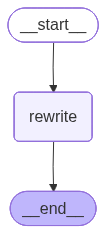

In [20]:
workflow

{'input': 'The quick brown fox jumps over the lazy dog.', 'output': 'The lazy dog is jumped over by the quick brown fox.'}
